<a href="https://colab.research.google.com/github/AbdelrahmanMohamed-Fathy/compilers-assignment-2/blob/main/Compilers.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Input and Verification


In [279]:
# @title google colab installations
!apt-get -qq install -y graphviz libgraphviz-dev pkg-config
!pip install pygraphviz automata-lib coloraide

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


In [280]:
from pydantic import BaseModel, Field, field_serializer, computed_field
from automata.fa.nfa import NFA
from typing import Optional, ClassVar
from enum import Enum, StrEnum
import json


sequential_cell_run = True

# @title reading regex string
if sequential_cell_run:
    regex = input("enter your regex: ")

In [281]:
# @title Function to return the opposite pair of a bracket
def get_pair(bracket: str) -> str:
    match bracket:
        case ")":
            return "("
        case "]":
            return "["
        case _:
            raise ValueError("Received none bracket")

In [296]:
# @title Check for correct brackets using a stack


def validate_regex(regex: str):
    stack = []
    allowed_symbols = {"+", "*", "?", "|", ".", "-"}
    allowed_symbols_except_dot = {"+", "*", "?", "|", "-"}
    for index, char in enumerate(regex):
        # checking start of regex
        if index == 0:
            if char in allowed_symbols and char != ".":
                raise ValueError("Regex group can not begin with a symbol")

        match char:
            # adding to stack if opening a bracket
            case "(" | "[":
                stack.append(char)
                # repeated check for start of regex on opening any group
                if regex[index + 1] in allowed_symbols and regex[index + 1] != ".":
                    raise ValueError("Regex group can not begin with a symbol")
            # popping from stack and checking if matching bracket pair
            case ")" | "]":
                if stack.pop() != get_pair(char):
                    raise ValueError("Invalid Order of brackets in regex")
            # checking range validation
            case "-":
                temp_stack = stack.copy()
                if len(temp_stack) == 0 or temp_stack.pop() != "[":
                    raise ValueError("Invalid Position of range in regex")
                elif (
                    regex[index - 1] > regex[index + 1]
                    or regex[index - 1] in ["[", "("]
                    or regex[index + 1] in ["[", "("]
                ):
                    raise ValueError("Invalid range character in regex")
            # checking for unallowed alphanumeric characters (brackets are already handled above)
            case char if not (char.isalnum() or char in allowed_symbols):
                raise ValueError("Unallowed non-alphanumeric character in regex")
            # checking allowed_symbols ins sequence
            case char if char in allowed_symbols_except_dot:
                if (
                    index < len(regex) - 1
                    and regex[index + 1] in allowed_symbols_except_dot
                ):
                    if not (char != "|" and regex[index + 1] == "|"):
                        raise ValueError(
                            "allowed symbols may not repeat after eachother in regex"
                        )
    if len(stack) != 0:
        raise ValueError("Invalid Number of brackets in regex")


if sequential_cell_run:
    validate_regex(regex)


In [283]:
# @title Regex groups pydantic model


class GroupModifier(StrEnum):
    PLUS = "+"
    STAR = "*"
    QUESTION_MARK = "?"


class GroupType(Enum):
    SEQUENCE = "sequence"
    OR = "or"


class RegexGroup(BaseModel):
    tokens: list["str | RegexGroup"] = Field(default_factory=list)
    type: GroupType = Field(default=GroupType.SEQUENCE)
    modifier: Optional[GroupModifier] = Field(default=None)

    def insert(self, token: str):
        self.tokens.append(token)

    def insert_group(self, group: "RegexGroup"):
        self.tokens.append(group)


In [284]:
# @title Parsing regex and seperating into tokens and groups


def check_for_modifier(group: RegexGroup, char: str):
    match char:
        case GroupModifier.PLUS:
            group.modifier = GroupModifier.PLUS
        case GroupModifier.STAR:
            group.modifier = GroupModifier.STAR
        case GroupModifier.QUESTION_MARK:
            group.modifier = GroupModifier.QUESTION_MARK
    return


def parse_regex(regex: str, ignore_brackets: bool = False) -> RegexGroup:
    token_groups: RegexGroup = RegexGroup()
    parse_index: int = 0
    while parse_index < len(regex):
        match regex[parse_index]:
            # Sequence group handling
            case "(" if not ignore_brackets:
                token_groups.insert_group(parse_regex(regex[parse_index + 1 :]))
                parse_index = regex.find(")", parse_index) + 1
                # skip plus and star related to group
                if parse_index < len(regex) and regex[parse_index] in list(
                    GroupModifier
                ):
                    parse_index += 1

            case ")" if not ignore_brackets:
                if parse_index + 1 < len(regex):
                    check_for_modifier(token_groups, regex[parse_index + 1])
                return token_groups
            # Or group handling
            case "[" if not ignore_brackets:
                token_groups.insert_group(
                    parse_regex(regex[parse_index + 1 :], ignore_brackets=True)
                )
                parse_index = regex.find("]", parse_index) + 1
                # skip plus and star related to group
                if parse_index < len(regex) and regex[parse_index] in list(
                    GroupModifier
                ):
                    parse_index += 1
            case "]":
                token_groups.type = GroupType.OR
                if parse_index + 1 < len(regex):
                    check_for_modifier(token_groups, regex[parse_index + 1])
                return token_groups

            case "|":
                old_group = token_groups
                end_index = regex.find(")", parse_index)
                if end_index == -1:
                    token_groups = RegexGroup(
                        tokens=[old_group, parse_regex(regex[parse_index + 1 :])],
                        type=GroupType.OR,
                    )
                    return token_groups
                else:
                    token_groups = RegexGroup(
                        tokens=[
                            RegexGroup(
                                tokens=[
                                    old_group,
                                    parse_regex(regex[parse_index + 1 : end_index]),
                                ],
                                type=GroupType.OR,
                            ),
                        ],
                    )
                    parse_index = end_index

            # literals handling
            case _:
                if parse_index + 1 < len(regex) and regex[parse_index + 1] == "+":
                    token_groups.insert_group(
                        RegexGroup(
                            tokens=[regex[parse_index]], modifier=GroupModifier.PLUS
                        )
                    )
                    parse_index += 2
                elif parse_index + 1 < len(regex) and regex[parse_index + 1] == "*":
                    token_groups.insert_group(
                        RegexGroup(
                            tokens=[regex[parse_index]], modifier=GroupModifier.STAR
                        )
                    )
                    parse_index += 2
                elif parse_index + 1 < len(regex) and regex[parse_index + 1] == "?":
                    token_groups.insert_group(
                        RegexGroup(
                            tokens=[regex[parse_index]],
                            modifier=GroupModifier.QUESTION_MARK,
                        )
                    )
                    parse_index += 2
                elif parse_index + 1 < len(regex) and regex[parse_index + 1] == "-":
                    token_groups.insert(regex[parse_index : parse_index + 3])
                    parse_index += 3
                else:
                    token_groups.insert(regex[parse_index])
                    parse_index += 1

    return token_groups


if sequential_cell_run:
    token_list = parse_regex(regex)
    print(token_list)

tokens=[RegexGroup(tokens=['k', 'o', 'f', 't', 'a', RegexGroup(tokens=['.'], type=<GroupType.SEQUENCE: 'sequence'>, modifier=<GroupModifier.PLUS: '+'>)], type=<GroupType.SEQUENCE: 'sequence'>, modifier=None), RegexGroup(tokens=['.'], type=<GroupType.SEQUENCE: 'sequence'>, modifier=None)] type=<GroupType.OR: 'or'> modifier=None


# Generating NFA


In [285]:
# @title Regex pydantic model


class RegexState(BaseModel):
    _name_counter: ClassVar[int] = 0
    name: str = Field(default="Unnamed")
    is_terminating_state: bool = Field(serialization_alias="isTerminatingState")
    children: dict[str, list["RegexState"]] = Field(
        default_factory=dict,
        serialization_alias="paths",
        exclude_if=lambda paths: not paths,
    )

    def __init__(self, **data):
        super().__init__(**data)
        self.name = f"S{RegexState._name_counter}"
        RegexState._name_counter += 1
        self.is_terminating_state = data["is_terminating_state"]
        self.children = data["children"]

    @field_serializer("children")
    def serialize_children(self, children: dict[str, list["RegexState"]], _info):
        return {k: [node.name for node in v] for k, v in children.items()}


In [286]:
# @title NFA pydantic model


class NfaModel(BaseModel):
    nodes: list[RegexState] = Field(default_factory=list, serialization_alias="States")

    def insert(self, node: RegexState):
        self.nodes.append(node)

    @computed_field(alias="startingState")
    @property
    def starting_node(self) -> str:
        return self.nodes[0].name


In [287]:
# @title Generation handler functions


def general_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    if group.modifier is not None:
        return modifier_handler(
            nfa=nfa, group=group, is_terminating=is_terminating, child=child
        )
    elif group.type == GroupType.SEQUENCE:
        return sequence_handler(
            nfa=nfa, group=group, is_terminating=is_terminating, child=child
        )
    else:
        return or_handler(
            nfa=nfa, group=group, is_terminating=is_terminating, child=child
        )


def sequence_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    initial_node = None
    final_node = None
    node_to_attach = None
    # we simply just loop on each token and keep adding them sequentially and connecting them with every loop
    for index, token in enumerate(group.tokens):
        if isinstance(token, str):
            (first, second) = base_handler(
                nfa=nfa,
                regex=token,
                is_terminating=False
                if index != len(group.tokens) - 1
                else is_terminating,
            )
        else:
            (first, second) = general_handler(
                nfa=nfa,
                group=token,
                is_terminating=False
                if index != len(group.tokens) - 1
                else is_terminating,
            )

        # we attach between sequential nodes here
        if node_to_attach:
            if "Ɛ" not in node_to_attach.children:
                node_to_attach.children["Ɛ"] = []
            node_to_attach.children["Ɛ"].append(first)

        node_to_attach = second

        # marking the initial node for return
        if not initial_node:
            initial_node = first

    # marking the final node as the last assigned node and attaching children if necessary
    final_node = second
    final_node.children = {child[0]: child[1]} if child else final_node.children
    return (initial_node, final_node)  # pyright: ignore[reportReturnType]


def or_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    initial_node = RegexState(is_terminating_state=False, children={"Ɛ": []})
    final_node = RegexState(
        is_terminating_state=is_terminating,
        children={child[0]: child[1]} if child else {},
    )
    nfa.insert(initial_node)
    # handle each indivisually and append it to the initial node while passing the final node as a child to all of them
    for token in group.tokens:
        if isinstance(token, str):
            initial_node.children["Ɛ"].append(
                base_handler(nfa=nfa, regex=token, child=("Ɛ", [final_node]))[0]
            )
        else:
            initial_node.children["Ɛ"].append(
                general_handler(nfa=nfa, group=token, child=("Ɛ", [final_node]))[0]
            )

    nfa.insert(final_node)
    return (initial_node, final_node)


# handling base case of 1 node going to a second node
def base_handler(
    nfa: NfaModel,
    regex: str,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    first = RegexState(
        is_terminating_state=False,
        children={regex: []},
    )
    second = RegexState(
        is_terminating_state=is_terminating,
        children={child[0]: child[1]} if child else {},
    )
    first.children[regex].append(second)
    nfa.insert(first)
    nfa.insert(second)
    return (first, second)


def modifier_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
):
    # we store the modifier and remove it from the group so we can give it back to the general handler
    modifier = group.modifier
    group.modifier = None

    # both star and question mark would make this true
    initial_node = RegexState(is_terminating_state=False, children={"Ɛ": []})
    final_node = RegexState(
        is_terminating_state=is_terminating,
        children={child[0]: child[1]} if child else {},
    )

    # now that modifier is removed we can call general handler and apply effects after
    nfa.insert(initial_node)
    (first, second) = general_handler(
        nfa=nfa, group=group, is_terminating=False, child=("Ɛ", [final_node])
    )
    initial_node.children["Ɛ"].append(first)
    nfa.insert(final_node)

    # both of these conditions capture all possibilities
    if modifier != GroupModifier.PLUS:
        initial_node.children["Ɛ"].append(final_node)
    if modifier != GroupModifier.QUESTION_MARK:
        if "Ɛ" not in second.children:
            second.children["Ɛ"] = []
        second.children["Ɛ"].append(first)

    return (initial_node, final_node)

In [288]:
# @title Calling the method to create NFA
def generate_nfa(regex_group: RegexGroup):
    nfa: NfaModel = NfaModel()
    general_handler(nfa=nfa, group=regex_group, is_terminating=True)
    return nfa


if sequential_cell_run:
    nfa = generate_nfa(token_list)
    print(nfa.model_dump_json(by_alias=True, indent=2))

{
  "States": [
    {
      "name": "S0",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S2",
          "S16"
        ]
      }
    },
    {
      "name": "S2",
      "isTerminatingState": false,
      "paths": {
        "k": [
          "S3"
        ]
      }
    },
    {
      "name": "S3",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S4"
        ]
      }
    },
    {
      "name": "S4",
      "isTerminatingState": false,
      "paths": {
        "o": [
          "S5"
        ]
      }
    },
    {
      "name": "S5",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S6"
        ]
      }
    },
    {
      "name": "S6",
      "isTerminatingState": false,
      "paths": {
        "f": [
          "S7"
        ]
      }
    },
    {
      "name": "S7",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S8"
        ]
      }
    },
    {
      "name": "S8",
      "isT

In [289]:
# @title Transforming data into desired output format
def print_output(nfa: NfaModel):
    nfa_json = {
        "startingState": nfa.starting_node,
        **{
            state.name: {
                "isTerminatingState": state.is_terminating_state,
                **{
                    key if key != "Ɛ" else "Epsilon": list(
                        [state.name for state in path]
                    )
                    for key, path in state.children.items()
                },
            }
            for state in nfa.nodes
        },
    }

    output = json.dumps(nfa_json, indent=2)
    print(output)

    with open("nfa.json", "w") as f:
        f.write(output)


if sequential_cell_run:
    print_output(nfa)

{
  "startingState": "S0",
  "S0": {
    "isTerminatingState": false,
    "Epsilon": [
      "S2",
      "S16"
    ]
  },
  "S2": {
    "isTerminatingState": false,
    "k": [
      "S3"
    ]
  },
  "S3": {
    "isTerminatingState": false,
    "Epsilon": [
      "S4"
    ]
  },
  "S4": {
    "isTerminatingState": false,
    "o": [
      "S5"
    ]
  },
  "S5": {
    "isTerminatingState": false,
    "Epsilon": [
      "S6"
    ]
  },
  "S6": {
    "isTerminatingState": false,
    "f": [
      "S7"
    ]
  },
  "S7": {
    "isTerminatingState": false,
    "Epsilon": [
      "S8"
    ]
  },
  "S8": {
    "isTerminatingState": false,
    "t": [
      "S9"
    ]
  },
  "S9": {
    "isTerminatingState": false,
    "Epsilon": [
      "S10"
    ]
  },
  "S10": {
    "isTerminatingState": false,
    "a": [
      "S11"
    ]
  },
  "S11": {
    "isTerminatingState": false,
    "Epsilon": [
      "S12"
    ]
  },
  "S12": {
    "isTerminatingState": false,
    "Epsilon": [
      "S14"
    ]
  },

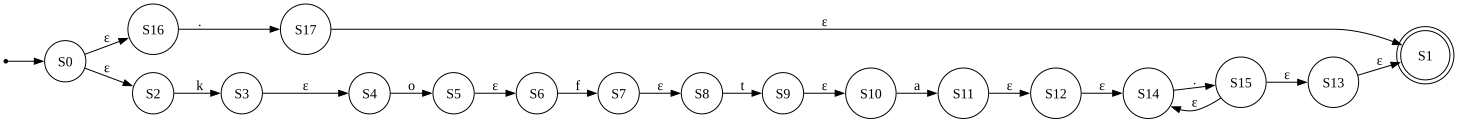

In [290]:
# @title Graphing
def graph_nfa(nfa: NfaModel):
    states = set([node.name for node in nfa.nodes])
    final_states = set([node.name for node in nfa.nodes if node.is_terminating_state])
    initial_state = nfa.starting_node
    input_symbols: set[str] = set({})
    [
        input_symbols.update([key for key in node.children.keys() if key != "Ɛ"])
        for node in nfa.nodes
    ]
    transitions = {
        node.name: {
            key if key != "Ɛ" else "": set([state.name for state in path])
            for key, path in node.children.items()
        }
        for node in nfa.nodes
        if len(node.children) > 0
    }

    graph = NFA(
        states=states,
        input_symbols=input_symbols,
        transitions=transitions,
        initial_state=initial_state,
        final_states=final_states,
    )

    return graph.show_diagram()


if sequential_cell_run:
    display(graph_nfa(nfa))

In [291]:
# @title Full run block

if not sequential_cell_run:
    regex = input()
    validate_regex(regex)
    nfa = generate_nfa(parse_regex(regex))
    print_output(nfa)
    display(graph_nfa(nfa))

# DFA and Minimization


In [292]:
# @title Helper Functions

# to python list (researched for errors)
def to_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return [x]


# epsilon-closure states
def epsilon_closure(nfa, state_set):
    closure = set(state_set)  # final set
    stack = list(state_set)  # temp

    while stack:
        current = stack.pop()
        info = nfa.get(current, {})
        eps_targets = info.get(
            "Epsilon"
        )  # edit for dif entry of epsilon (sign or e for ex.)
        for i in to_list(eps_targets):
            if i not in closure:
                closure.add(i)
                stack.append(i)

    return closure


def move(
    nfa, state_set, symbol
):  # find the next state if a symbol was inputed as A for ex. S0 -A-> S1, result would be S1
    result = set()
    for s in state_set:
        info = nfa.get(s, {})  # full line info of the state
        targets = info.get(symbol)  # A : S1 -> S1
        for i in to_list(targets):
            result.add(i)
    return result


def find_subset_index(subsets, subset):  # find index of a subset in a list of subsets
    for i, s in enumerate(subsets):
        if s == subset:
            return i
    return -1


def dfa_state_name(index):  # helper to name new DFA states
    return "S" + str(index + 1)

In [293]:
# @title NFA to DFA conversion
def nfa_to_dfa(nfa):
    start_state = nfa["startingState"]

    symbols = set()  # find all symbols used in the NFA (A for ex.)
    for name, info in nfa.items():
        if name == "startingState":
            continue
        for key in info:
            if key not in ("isTerminatingState", "Epsilon"):
                symbols.add(key)

    start_closure = epsilon_closure(nfa, {start_state})

    dfa_subsets = [start_closure]

    dfa = {"startingState": dfa_state_name(0)}

    i = 0  # for naming

    while i < len(dfa_subsets):
        subset = dfa_subsets[i]  # current subset of NFA states
        state_name = dfa_state_name(i)

        terminating = False
        for s in subset:  # loop over all of the states in the DFA subset to check if any is terminating state
            if nfa.get(s, {}).get("isTerminatingState", False):
                terminating = True
                break

        if (
            state_name not in dfa
        ):  # create DFA state in the output if not already created(first state)
            dfa[state_name] = {}

        dfa[state_name]["isTerminatingState"] = terminating

        # build transitions from this DFA state
        for sym in symbols:
            direct = move(nfa, subset, sym)  # follow sym
            if not direct:
                continue

            closure = epsilon_closure(nfa, direct)

            j = find_subset_index(
                dfa_subsets, closure
            )  # check if this subset already exist as a DFA state
            if j == -1:
                dfa_subsets.append(closure)
                j = len(dfa_subsets) - 1

            target_name = dfa_state_name(j)
            dfa[state_name][sym] = target_name

        i += 1

    return dfa


with open("nfa.json", "r") as file:
    nfa_json = json.load(file)

dfa = nfa_to_dfa(nfa_json)
print(json.dumps(dfa, indent=2))


{
  "startingState": "S1",
  "S1": {
    "isTerminatingState": false,
    "k": "S2",
    ".": "S3"
  },
  "S2": {
    "isTerminatingState": false,
    "o": "S4"
  },
  "S3": {
    "isTerminatingState": true
  },
  "S4": {
    "isTerminatingState": false,
    "f": "S5"
  },
  "S5": {
    "isTerminatingState": false,
    "t": "S6"
  },
  "S6": {
    "isTerminatingState": false,
    "a": "S7"
  },
  "S7": {
    "isTerminatingState": false,
    ".": "S8"
  },
  "S8": {
    "isTerminatingState": true,
    ".": "S8"
  }
}
